<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

## Data getters

Functions to retrieve specific data components are provided, aiding in the organization and preprocessing of datasets.

In [0]:
#| echo: false
#| output: asis
show_doc(get_images)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L109){target="_blank" style="float:right; font-size:smaller"}

### get_images

```python

def get_images(
    path:str | pathlib.Path, folders:str | list[str] | None=None, recurse:bool=True, filename_filter:Union=None
)->L:


```

*Get image files from a list of folders or a glob expression.*

In [0]:
#| echo: false
#| output: asis
show_doc(get_gt)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L154){target="_blank" style="float:right; font-size:smaller"}

### get_gt

```python

def get_gt(
    path_gt, # The base directory where the ground truth files are stored, or a file path from which to derive the parent directory.
    gt_file_name:str='avg50.png', # The name of the ground truth file.
):


```

*The [`get_gt`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#get_gt) function retrieves ground truth data, essential for supervised learning tasks. *
It ensures that the correct labels or annotations are associated with each data sample.

This function constructs a path to a ground truth file based on the given `path_gt` and `gt_file_name`.    
It uses a lambda function to create a new path by appending `gt_file_name` to 
the parent directory of the input file, as specified by `path_gt`.

Returns a callable: A function that takes a single argument (a filename) and returns a Path object 
               representing the full path to the ground truth file. When called with a filename, 
               this function constructs the path by combining `path_gt` or the parent directory of 
               the filename with `gt_file_name`.

The [`get_target`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#get_target) function constructs and returns functions for generating file paths to "target" files based on given input parameters. 
This function is particularly useful for tasks where the target files are stored in a different directory or have a different naming convention compared to the input files.

In [0]:
#| echo: false
#| output: asis
show_doc(get_target)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L181){target="_blank" style="float:right; font-size:smaller"}

### get_target

```python

def get_target(
    path:str, # The base directory where the files are located. This should be a string representing an absolute or relative path.
    same_filename:bool=True, # If True, the target file name will match the original file name; otherwise, it will use the specified prefix.
    same_foldername:bool=False, # If True, the target folder name will match the original folder name; otherwise, it will use the specified prefix.
    target_file_prefix:str='target', # The prefix to insert into the target file name if `same_filename` is False.
    signal_file_prefix:str='signal', # The prefix used in the original file names that should be replaced by the target prefix.
    map_foldername:bool=False, # If True, the target folder name will match the original folder name; otherwise, it will use the specified prefix.
    target_folder_prefix:str='target', # The prefix to insert into the target folder name if `same_foldername` is False.
    signal_folder_prefix:str='signal', # The prefix used in the original folder names that should be replaced by the target prefix.
    relative_path:bool=False, # If True, it indicates that the path is relative to the parent folder in the path where the input files are located.
):


```

*Constructs and returns functions for generating file paths to "target" files based on given input parameters.*

This function defines two nested helper functions within its scope: 

    - `construct_target_filename(file_name)`: Constructs a target file name by inserting the specified prefix into the original file name.
    - `generate_target_path(file_name)`: Generates a path to the target file based on whether `same_filename` is set to True or False.

The main function returns the appropriate helper function based on the value of `same_filename`.

Returns a callable: A function that takes a file name as input and returns its corresponding target file path based on the specified parameters.

The function [`get_target`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#get_target) can be used to look for target files in different folders using either absolute or relative paths:

In [ ]:
print(get_target('train_folder/target', same_filename=False)('../signal/signal01.tif'))
print(get_target('target', relative_path=True)('../train_folder/signal/image01.tif'))

train_folder/target/target01.tif
../train_folder/target/image01.tif


...and it can look for target files with different names but same numbering:

In [ ]:
print(get_target('GT', relative_path=True, same_filename=False, target_file_prefix="image_clean", signal_file_prefix="image_noisy")('train_folder/signal/image_noisy_01.tif'))

train_folder/GT/image_clean_01.tif


It also supports more general cases:

In [ ]:
print(get_target('GT', relative_path=True, same_filename=False, target_file_prefix="clean", signal_file_prefix="noisy")('train_folder/signal/01_image_noisy_dataset.tif'))

train_folder/GT/01_image_clean_dataset.tif


In [ ]:
print(get_target('', relative_path=True, map_foldername=True, target_folder_prefix="GT", signal_folder_prefix="signal")('train_folder/signal_01/01_1.tif'))

train_folder/GT_01/01_1.tif


For tasks involving unsupervised denoising or noise analysis, [`get_noisy_pair`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#get_noisy_pair) retrieves pairs of noisy data, enabling the training of models such as N2N.

In [0]:
#| echo: false
#| output: asis
show_doc(get_noisy_pair)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L252){target="_blank" style="float:right; font-size:smaller"}

### get_noisy_pair

```python

def get_noisy_pair(
    fn
):


```

*Get another "noisy" version of the input file by selecting a file from the same directory.*

This function first retrieves all image files in the directory of the input file `fn` (excluding subdirectories). 
It then selects one of these files at random, ensuring that it is not the original file itself to avoid creating a trivial "noisy" pair.

Parameters: 

    fn (Path or str): The path to the original image file. This should be a Path object but accepts string inputs for convenience.

Returns: 

    Path: A Path object pointing to the selected noisy file.

## Data Display

Visualization functions are included to display batches of data and model results, aiding in qualitative assessments and debugging.

In [0]:
#| echo: false
#| output: asis
show_doc(show_batch)

In [0]:
#| echo: false
#| output: asis
show_doc(show_batch)

In [0]:
#| echo: false
#| output: asis
show_doc(show_batch)

### show_batch
> ```  
> show_batch (x:BioImageBase, y:BioImageBase, samples,
>             ctxs=None, max_n:int=10, nrows:int=None, ncols:int=None,
>             figsize:tuple=None, **kwargs)
> ```


The [`show_batch`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#show_batch) function visualizes a batch of data samples, allowing users to inspect the input data and verify preprocessing steps.

Returns: List[Context]: A list of contexts after displaying the images and labels.

| | Type           | Default     | Details                                                         |
|-----------|-----|-------------|-----------------------------------------------------------------|
| x              | BioImageBase | | The input image data.                                           |
| y              | BioImageBase | | The target label data.                                          |
| samples        |             | | List of sample indices to display.                              |
| ctxs           | NoneType     | | List of contexts for displaying images. If None, create new ones using `get_grid()`. |
| max_n          | int          | 10 | Maximum number of samples to display.        |
| nrows          | int          | None | Number of rows in the grid if `ctxs` are not provided.      |
| ncols          | int          | None | Number of columns in the grid if `ctxs` are not provided.   |
| figsize        | tuple        | None | Figure size for the image display.                          |
| kwargs         |            | | Additional keyword arguments.                                   |


In [0]:
#| echo: false
#| output: asis
show_doc(show_results)

In [0]:
#| echo: false
#| output: asis
show_doc(show_results)

In [0]:
#| echo: false
#| output: asis
show_doc(show_results)

### show_results
> ```
> show_results (x: BioImageBase, y: BioImageBase, samples,
>               outs, ctxs=None, max_n=10, figsize=None, **kwargs)
> ```

After model inference, [`show_results`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#show_results) displays the model's predictions alongside the ground truth, facilitating the evaluation of model performance.

Returns:

List[Context]: A list of contexts after displaying the images and labels.


|   | Type           | Default     | Details                                                         |
|-----------|-----|-------------|-----------------------------------------------------------------|
| x              | BioImageBase | | The input image data.                                           |
| y              | BioImageBase | | The target label data.                                          |
| samples        |             | | List of sample indices to display.                              |
| outs           |          |   | List of output predictions corresponding to the samples. |
| ctxs           | NoneType     | | List of contexts for displaying images. If None, create new ones using `get_grid()`. |
| max_n          | int        | 10  | 
| figsize        | tuple        | None | Figure size for the image display.                          |
| kwargs         |            | | Additional keyword arguments.                                   |


## Data Handling

In [0]:
#| echo: false
#| output: asis
show_doc(split_dataframe)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L657){target="_blank" style="float:right; font-size:smaller"}

### split_dataframe

```python

def split_dataframe(
    input_data:Union, splitter:Callable=RandomSplitter, save_mode:str='separate', split_column:str='split',
    is_valid_column:str='is_valid', train_path:str='train.csv', test_path:str='test.csv', valid_path:str='valid.csv',
    combined_path:str='dataset.csv', train_valid_path:str='train_valid.csv', data_save_path:Optional=None,
    kwargs:VAR_KEYWORD
)->tuple:


```

*Split a dataset into multiple subsets.*

The input dataset can be provided either as a pandas DataFrame
or as a path to a CSV file. The splitting logic is delegated to
the provided ``splitter`` callable.

The splitter may return either:

- ``(train_df, valid_df)``
- ``(train_df, valid_df, test_df)``

The resulting datasets can optionally be saved in different formats:

- ``"separate"``
    Save each split as an individual CSV file.

- ``"single"``
    Save all splits into a single CSV file with an additional
    column identifying the split name.

- ``"train_valid_together"``
    Save the test set separately while combining train and
    validation datasets into one CSV file with an ``is_valid``
    boolean column.

Args:
    input_data:
        Input dataset as either a pandas DataFrame or a CSV file path.

    splitter:
        Callable responsible for splitting the dataset.

    save_mode:
        Saving strategy for output datasets.
        One of:
        ``"separate"``,
        ``"single"``,
        ``"train_valid_together"``.

    split_column:
        Column name used when ``save_mode="single"``.

    is_valid_column:
        Column name used when
        ``save_mode="train_valid_together"``.

    train_path:
        Filename for the train dataset.

    test_path:
        Filename for the test dataset.

    valid_path:
        Filename for the validation dataset.

    combined_path:
        Filename used when saving all splits into one file.

    train_valid_path:
        Filename used when saving combined
        train + validation data.

    data_save_path:
        Directory where datasets will be saved.
        If ``None``, datasets are not saved.

    **kwargs:
        Additional keyword arguments passed to the splitter.

Returns:
    tuple:
        Split datasets returned by the splitter.

Raises:
    TypeError:
        If ``input_data`` is neither a DataFrame nor a file path.

    ValueError:
        If ``save_mode`` is invalid or the splitter
        returns an unsupported number of outputs.

In [0]:
#| echo: false
#| output: asis
show_doc(build_df)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L846){target="_blank" style="float:right; font-size:smaller"}

### build_df

```python

def build_df(
    filenames:Union, # List of file names to process
    functions:Callable, # One or more functions that take a filename and return a string (e.g., for generating target paths).
    function_names:Union=None, # Optional column names for the function outputs. If None, function.__name__ is used.
    filename_col:str='filename', # Column name for the input filenames.
    output_csv:Union=None, # If provided, saves the full dataframe to this CSV path.
    split:bool=False, # If True, applies split_dataframe to the generated dataframe.
    split_kwargs:Optional=None, # Keyword arguments passed to split_dataframe.
)->Union:


```

*Create a DataFrame from filenames and one or more transformation functions.*

In [0]:
#| echo: false
#| output: asis
show_doc(build_df_from_folder)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L895){target="_blank" style="float:right; font-size:smaller"}

### build_df_from_folder

```python

def build_df_from_folder(
    path:str | pathlib.Path,
    functions:Callable, # One or more functions that take a filename and return a string (e.g., for generating target paths).
    function_names:Union=None, # Optional column names for the function outputs. If None, function.__name__ is used.
    output_csv:Union=None, # If provided, saves the full dataframe to this CSV path.
    subfolders:str | list[str] | None=None, recurse:bool=True, filename_filter:Union=None,
    split:bool=False, # If True, applies split_dataframe to the generated dataframe.
    split_kwargs:Optional=None, # Keyword arguments passed to split_dataframe.
)->Union:


```

*Create a DataFrame from filenames and one or more transformation functions.*

## Preprocessing

The module provides functions for data preprocessing, including patch extraction and dimensionality reduction, essential for preparing data for machine learning models.

### Image Splitters

In [ ]:
#| echo: false
#| output: asis
show_doc(SlidingWindowSplitter)

---

### SlidingWindowSplitter

```python

def SlidingWindowSplitter(
    patch_size:Sequence[int] | int, overlap:Sequence[float] | float | Sequence[int] | int=0.0,
    offset:Sequence[int] | int=0, filter_fn:Callable | None=None, pad_mode:str | None='constant',
    pad_value:float | int=0, device:torch.device | str | None=None
)->None:


```

*Splits the input into patches with sliding window strategy and a possible overlap.*
It also allows offsetting the starting position and filtering the patches.

Args:
    patch_size : the size of the patches to be generated.
    offset: the amount of offset for the patches with respect to the original input.  Defaults to 0.
    overlap: the amount of overlap between patches in each dimension. It can be either a float in
        the range of [0.0, 1.0) that defines relative overlap to the patch size, or it can be a non-negative int
        that defines number of pixels for overlap. Defaults to 0.0.
    filter_fn: a callable to filter patches. It should accepts exactly two parameters (patch, location), and
        return True for a patch to keep. Defaults to no filtering.
    pad_mode: string define the mode for `torch.nn.functional.pad`. The acceptable values are
        `"constant"`, `"reflect"`, `"replicate"`, `"circular"` or `None`. Default to `"constant"`.
        If None, no padding will be applied, so it will drop the patches crossing the border of
        the image (either when the offset is negative or the image is non-divisible by the patch_size).
    pad_value: the value for `"constant"` padding. Defaults to 0.
    device: the device where the patches are generated. Defaults to the device of inputs.

Note:
    When a scaler value is provided for `patch_size`, `offset`, or `overlap`,
        it is broadcasted to all the spatial dimensions.

In [ ]:
class RandomPatchSplitter(Splitter):
    """
    Extract random patches from input tensors.

    Args:
        patch_size: size of patches
        num_patches: number of patches to sample
        offset: offset for sampling
        filter_fn: optional filtering function (patch, location) -> bool
        pad_mode: padding mode
        pad_value: padding value
        device: torch device
    """

    def __init__(
        self,
        patch_size: Sequence[int] | int,
        num_patches: int,
        offset: Sequence[int] | int = 0,
        filter_fn: Callable | None = None,
        pad_mode: str | None = "constant",
        pad_value: float | int = 0,
        device: torch_device | str | None = None,
    ):
        super().__init__(patch_size=patch_size, device=device)
        self.num_patches = num_patches
        self.offset = offset
        self.filter_fn = self._validate_filter_fn(filter_fn)
        self.pad_mode = pad_mode
        self.pad_value = pad_value

    @staticmethod
    def _validate_filter_fn(filter_fn):
        if callable(filter_fn):
            sig = signature(filter_fn)
            n_params = len(sig.parameters)
            num_pos_params = len([v for v in sig.parameters.values() if v.default is _empty])
            if n_params < 2:
                raise ValueError("`filter_fn` must accept (patch, location)")
            elif num_pos_params > 2:
                raise ValueError("`filter_fn` can have at most 2 positional params")
        elif filter_fn is not None:
            raise ValueError("`filter_fn` must be callable or None")
        return filter_fn

    def _get_valid_shape_parameters(self, spatial_shape):
        spatial_ndim = len(spatial_shape)
        patch_size = ensure_tuple_rep(self.patch_size, spatial_ndim)
        offset = ensure_tuple_rep(self.offset, spatial_ndim)

        for off, ps, sh in zip(offset, patch_size, spatial_shape):
            if off < -ps:
                raise ValueError("Offset too negative")
            if off >= sh:
                raise ValueError("Offset exceeds input size")

        return patch_size, offset

    def _get_patch(self, inputs, location, patch_size):
        slices = (slice(None),) * 2 + tuple(
            slice(loc, loc + ps) for loc, ps in zip(location, patch_size)
        )
        return inputs[slices]

    def _sample_location(self, spatial_shape, patch_size, offset):
        loc = []
        for sh, ps, off in zip(spatial_shape, patch_size, offset):
            low = max(off, 0)
            high = max(sh - ps, 0)
            if high < low:
                # fallback (will require padding if enabled)
                loc.append(low)
            else:
                loc.append(random.randint(low, high))
        return tuple(loc)
    
    def get_input_shape(self, inputs: Any) -> tuple:
        return tuple(inputs.shape[2:])

    def get_padded_shape(self, spatial_shape: Sequence[int]) -> tuple:
        return tuple(spatial_shape)
    
    def __call__(self, inputs: Any):
        spatial_shape = tuple(inputs.shape[2:])
        patch_size, offset = self._get_valid_shape_parameters(spatial_shape)

        passed_patches = 0

        attempts = 0
        max_attempts = self.num_patches * 10  # avoid infinite loops

        while passed_patches < self.num_patches and attempts < max_attempts:
            loc = self._sample_location(spatial_shape, patch_size, offset)
            patch = self._get_patch(inputs, loc, patch_size)

            if self.filter_fn is None or self.filter_fn(patch, loc):
                passed_patches += 1
                yield patch, loc

            attempts += 1

In [ ]:
data = torchTensor(1, 3, 100, 100)  # Example data
patch_size = (64,64)
overlap = 0.5
patches = SlidingWindowSplitter(patch_size, overlap)(data)

for patch, loc in patches:
    print(patch.shape, f"X/{loc}")

torch.Size([1, 3, 64, 64]) X/(0, 0)
torch.Size([1, 3, 64, 64]) X/(0, 32)
torch.Size([1, 3, 64, 64]) X/(0, 64)
torch.Size([1, 3, 64, 64]) X/(32, 0)
torch.Size([1, 3, 64, 64]) X/(32, 32)
torch.Size([1, 3, 64, 64]) X/(32, 64)
torch.Size([1, 3, 64, 64]) X/(64, 0)
torch.Size([1, 3, 64, 64]) X/(64, 32)
torch.Size([1, 3, 64, 64]) X/(64, 64)


In [ ]:
patches = RandomPatchSplitter(patch_size, 3)(data)

for patch, loc in patches:
    print(patch.shape, f"X/{loc}")

torch.Size([1, 3, 64, 64]) X/(0, 36)
torch.Size([1, 3, 64, 64]) X/(1, 12)
torch.Size([1, 3, 64, 64]) X/(15, 24)


### Patches

In [0]:
#| echo: false
#| output: asis
show_doc(ProcessImageDataset)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L1169){target="_blank" style="float:right; font-size:smaller"}

### ProcessImageDataset

```python

def ProcessImageDataset(
    data_paths, output_folder, output_filename, patch_size, input_class:MetaResolver=BioImageBase,
    target_class:MetaResolver=BioImageBase, image_splitter:ABCMeta=SlidingWindowSplitter,
    splitter:function=RandomSplitter, colmap:NoneType=None, csv:bool=True, csv_filename:NoneType=None,
    image_transforms:NoneType=None, patch_transforms:NoneType=None, compression:NoneType=None, kwargs:VAR_KEYWORD
):


```

*Prepare an image dataset by:*

1. Loading dataset metadata
2. Optionally splitting the dataset
3. Extracting patches
4. Saving patches into HDF5
5. Optionally saving patch metadata CSV

In [ ]:
ProcessImageDataset('./data_examples','./_test_tfms','dummy_dataset', (64,64), overlap=0, colmap = {"image": "Confocal_BPAE_B","gt": "Confocal_BPAE_B"})

Splitting dataset...

Processing split: train


100%|██████████| 5/5 [00:00<00:00, 12.23it/s]



Processing split: valid


100%|██████████| 2/2 [00:00<00:00, 15.80it/s]


Dataset processing complete. HDF5 file saved to: ./_test_tfms/dummy_dataset.h5
Patch information saved to CSV: ./_test_tfms/dummy_dataset.csv


#### Example 

In [ ]:
from monai.transforms import GaussianSmoothd
from bioMONAI.io import hdf5_loader
from bioMONAI.visualize import show_image

In [ ]:
# List of transformations defined from the bioMONAI transforms module 
transforms_list = [
    GaussianSmoothd('image', sigma=3), 
    GaussianSmoothd('gt', sigma=1), 
]

In [ ]:
data_paths = './data_examples'
# For the sake of simplicity, in this example we use the same folder for ground truth
colmap = {"image": "Confocal_BPAE_B","gt": "Confocal_BPAE_B"} 
output_folder = './_test_tfms'
patch_size = (64,64)
overlap = 0
ProcessImageDataset(
    data_paths, 
    output_folder,
    'patches_dataset',
    patch_size, 
    overlap=overlap, 
    colmap=colmap, 
    image_transforms=transforms_list, 
    random_seed=42, 
    csv_filename='my_patches_datasets.csv'
    )

Splitting dataset...

Processing split: train


100%|██████████| 5/5 [00:00<00:00, 12.88it/s]



Processing split: valid


100%|██████████| 2/2 [00:00<00:00, 13.42it/s]


Dataset processing complete. HDF5 file saved to: ./_test_tfms/patches_dataset.h5
Patch information saved to CSV: ./_test_tfms/my_patches_datasets.csv


In [ ]:
pd.read_csv('./_test_tfms/my_patches_datasets.csv').head()

,image,gt,image_name,split,patch_idx,location
0,train/HV110_P0500510003/X/0,train/HV110_P0500510003/y/0,HV110_P0500510003,train,0,"(0, 0)"
1,train/HV110_P0500510003/X/1,train/HV110_P0500510003/y/1,HV110_P0500510003,train,1,"(0, 64)"
2,train/HV110_P0500510003/X/2,train/HV110_P0500510003/y/2,HV110_P0500510003,train,2,"(0, 128)"
3,train/HV110_P0500510003/X/3,train/HV110_P0500510003/y/3,HV110_P0500510003,train,3,"(0, 192)"
4,train/HV110_P0500510003/X/4,train/HV110_P0500510003/y/4,HV110_P0500510003,train,4,"(0, 256)"


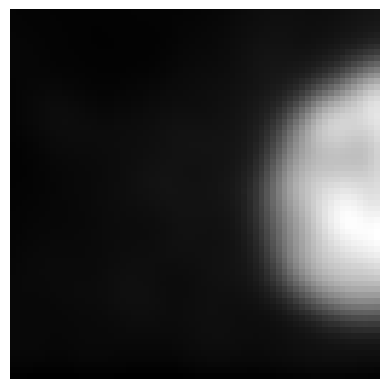

In [ ]:
file_path = output_folder + '/patches_dataset.h5/' + pd.read_csv('./_test_tfms/my_patches_datasets.csv')['image'][1]
im , meta, affine = hdf5_loader()(file_path)
show_image(im)

In [ ]:
meta

{'affine': array([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]]),
 'channel_names': "['Channel:0:0']",
 'channels': '1',
 'current_resolution_level': '0',
 'current_scene': 'Image:0',
 'current_scene_index': '0',
 'depth': '1',
 'dimension_properties': '[[None, None], [None, None], [None, None], [None, None], [None, None]]',
 'dims': "{'T': 1, 'C': 1, 'Z': 1, 'Y': 512, 'X': 512}",
 'dtype': 'uint8',
 'filepath': 'data_examples/Confocal_BPAE_B/HV110_P0500510003.png',
 'format': 'PNG',
 'frames': 'None',
 'height': '512',
 'kind': 'image',
 'layout': 'CZYX',
 'metadata': "{'mode': 'L', 'shape': [512, 512]}",
 'mode': 'L',
 'mosaic_tile_dims': 'None',
 'ome_metadata': '<error: >',
 'original_channel_dim': '0',
 'patch_size': '(64, 64)',
 'patch_transforms': 'None',
 'physical_pixel_sizes': '[None, None, None]',
 'reader': "{'extension': 'png', 'imageio_read_mode': '?'}",
 'resolution_level_dims': '{0: [512, 512]}',
 'resolution_levels': '[

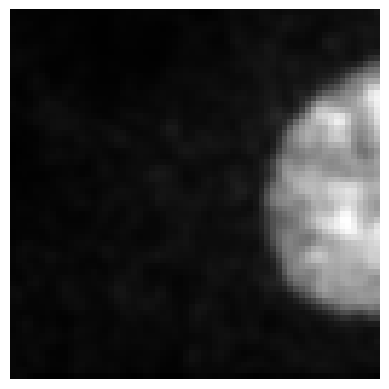

In [ ]:
file_path = output_folder + '/patches_dataset.h5/' + pd.read_csv('./_test_tfms/my_patches_datasets.csv')['gt'][1]
im , meta, affine = hdf5_loader()(file_path)
show_image(im)

In [ ]:
meta

{'affine': array([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]]),
 'channel_names': "['Channel:0:0']",
 'channels': '1',
 'current_resolution_level': '0',
 'current_scene': 'Image:0',
 'current_scene_index': '0',
 'depth': '1',
 'dimension_properties': '[[None, None], [None, None], [None, None], [None, None], [None, None]]',
 'dims': "{'T': 1, 'C': 1, 'Z': 1, 'Y': 512, 'X': 512}",
 'dtype': 'uint8',
 'filepath': 'data_examples/Confocal_BPAE_B/HV110_P0500510003.png',
 'format': 'PNG',
 'frames': 'None',
 'height': '512',
 'kind': 'image',
 'layout': 'CZYX',
 'metadata': "{'mode': 'L', 'shape': [512, 512]}",
 'mode': 'L',
 'mosaic_tile_dims': 'None',
 'ome_metadata': '<error: >',
 'original_channel_dim': '0',
 'patch_size': '(64, 64)',
 'patch_transforms': 'None',
 'physical_pixel_sizes': '[None, None, None]',
 'reader': "{'extension': 'png', 'imageio_read_mode': '?'}",
 'resolution_level_dims': '{0: [512, 512]}',
 'resolution_levels': '[

In [ ]:
affine

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [ ]:
data_paths = './data_examples'
# For the sake of simplicity, in this example we use the same folder for ground truth
colmap = {"image": "Confocal_BPAE_B","gt": "Confocal_BPAE_B"} 
output_folder = './_test_tfms'
patch_size = (64,64)
ProcessImageDataset(
    data_paths, 
    output_folder,
    'patches_dataset_random',
    patch_size, 
    num_patches=3,
    colmap=colmap, 
    patch_transforms=transforms_list, 
    image_splitter=RandomPatchSplitter, 
    random_seed=42, 
    )

Splitting dataset...

Processing split: train


100%|██████████| 5/5 [00:00<00:00, 27.58it/s]



Processing split: valid


100%|██████████| 2/2 [00:00<00:00, 28.43it/s]


Dataset processing complete. HDF5 file saved to: ./_test_tfms/patches_dataset_random.h5
Patch information saved to CSV: ./_test_tfms/patches_dataset_random.csv


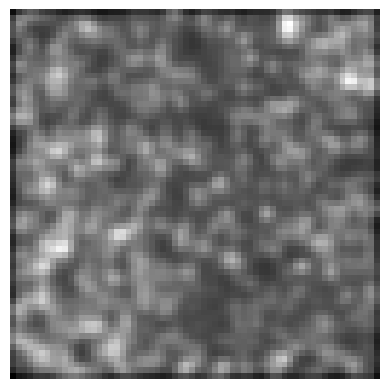

In [ ]:
file_path = output_folder + '/patches_dataset_random.h5/' + pd.read_csv('./_test_tfms/patches_dataset_random.csv')['gt'][1]
im , meta, affine = hdf5_loader()(file_path)
show_image(im)

In [ ]:
meta

{'affine': array([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]]),
 'channel_names': "['Channel:0:0']",
 'channels': '1',
 'current_resolution_level': '0',
 'current_scene': 'Image:0',
 'current_scene_index': '0',
 'depth': '1',
 'dimension_properties': '[[None, None], [None, None], [None, None], [None, None], [None, None]]',
 'dims': "{'T': 1, 'C': 1, 'Z': 1, 'Y': 512, 'X': 512}",
 'dtype': 'uint8',
 'filepath': 'data_examples/Confocal_BPAE_B/HV110_P0500510005.png',
 'format': 'PNG',
 'frames': 'None',
 'height': '512',
 'kind': 'image',
 'layout': 'CZYX',
 'metadata': "{'mode': 'L', 'shape': [512, 512]}",
 'mode': 'L',
 'mosaic_tile_dims': 'None',
 'ome_metadata': '<error: >',
 'original_channel_dim': '0',
 'patch_size': '(64, 64)',
 'patch_transforms': "{'GaussianSmoothd': {'__class__': 'GaussianSmoothd', 'keys': ('gt',), 'allow_missing_keys': False, 'converter': {'__class__': 'GaussianSmooth', 'sigma': 1, 'approx': 'erf'}}}",
 'physi